Ref

--- ĐANG TẢI DỮ LIỆU TỪ SQL SERVER ---
Dữ liệu sau khi tổng hợp theo giờ: (34168, 1)


,Total_Power
DateTime,
2006-12-16 17:00:00,152.024
2006-12-16 18:00:00,217.932
2006-12-16 19:00:00,204.014
2006-12-16 20:00:00,196.114
2006-12-16 21:00:00,183.388


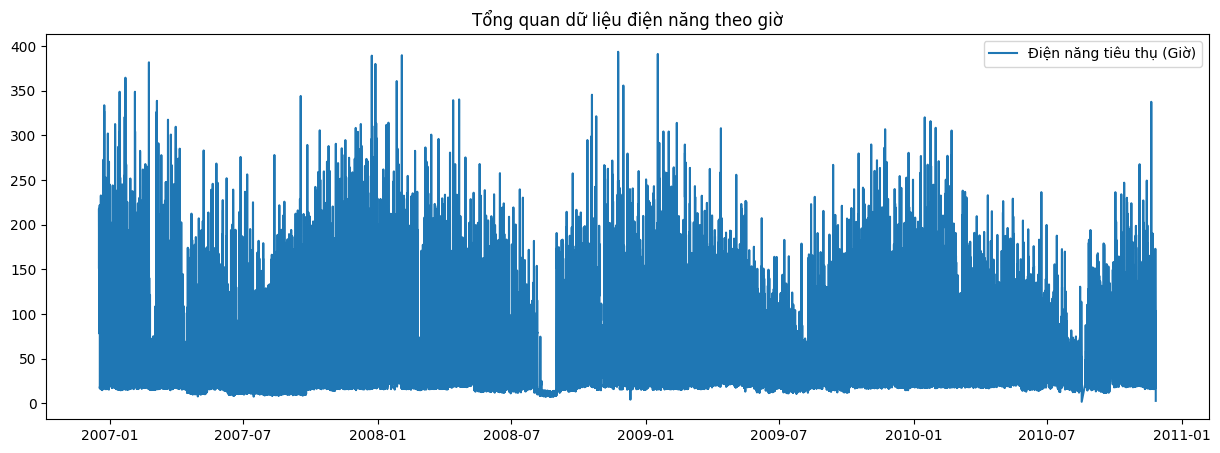

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
import sys
import os

# Import kết nối DB
sys.path.append(os.path.abspath(''))
from db_connect import get_db_engine

print("--- ĐANG TẢI DỮ LIỆU TỪ SQL SERVER ---")
query = """
SELECT 
    d.FullDate,
    t.Hour,
    SUM(f.Global_active_power) as Total_Power
FROM Fact_PowerConsumption f
JOIN Dim_Date d ON f.DateKey = d.DateKey
JOIN Dim_Time t ON f.TimeKey = t.TimeKey
GROUP BY d.FullDate, t.Hour
ORDER BY d.FullDate, t.Hour
"""
engine = get_db_engine()
df = pd.read_sql(query, engine)


df['DateTime'] = pd.to_datetime(df['FullDate'].astype(str) + ' ' + df['Hour'].astype(str) + ':00:00')
df.set_index('DateTime', inplace=True)
df.drop(['FullDate', 'Hour'], axis=1, inplace=True)

print(f"Dữ liệu sau khi tổng hợp theo giờ: {df.shape}")
display(df.head())


plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Total_Power'], label='Điện năng tiêu thụ (Giờ)')
plt.title('Tổng quan dữ liệu điện năng theo giờ')
plt.legend()
plt.show()

Data Preparing

In [3]:

def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df[['Total_Power']])

SEQ_LENGTH = 48  

X, y = create_sequences(data_scaled, SEQ_LENGTH)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Kích thước tập Train mới: X={X_train.shape}")

Kích thước tập Train mới: X=(27296, 48, 1)


Linear Regression

In [4]:
print("--- TRAINING LINEAR REGRESSION ---")
X_train_LR = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_test_LR = X_test.reshape(X_test.shape[0], X_test.shape[1])

model_lr = LinearRegression()
model_lr.fit(X_train_LR, y_train)
y_pred_lr = model_lr.predict(X_test_LR)


y_test_inv = scaler.inverse_transform(y_test)
y_pred_lr_inv = scaler.inverse_transform(y_pred_lr)

print("Xong Linear Regression.")

--- TRAINING LINEAR REGRESSION ---
Xong Linear Regression.


XGBoost

In [ ]:
print("--- TRAINING XGBOOST ---")

model_xgb = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000, 
    learning_rate=0.05, 
    max_depth=6,
    random_state=42,
    n_jobs=-1 
)
model_xgb.fit(X_train_LR, y_train)
y_pred_xgb = model_xgb.predict(X_test_LR)


y_pred_xgb_inv = scaler.inverse_transform(y_pred_xgb.reshape(-1, 1))
print("Xong XGBoost.")

--- TRAINING XGBOOST ---
Xong XGBoost.


MLP

In [6]:
print("--- TRAINING NEURAL NETWORK ---")
model_mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32), 
    activation='relu', 
    solver='adam', 
    max_iter=2000, 
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.1, 
    random_state=42
)

# Huấn luyện
model_mlp.fit(X_train_LR, y_train)

# Dự báo
y_pred_mlp = model_mlp.predict(X_test_LR)


y_pred_mlp_inv = scaler.inverse_transform(y_pred_mlp.reshape(-1, 1))

print("Xong Neural Network (MLP - Tuned).")
print(f"Số vòng lặp thực tế đã chạy: {model_mlp.n_iter_}")
print(f"Loss cuối cùng: {model_mlp.loss_}")

--- TRAINING NEURAL NETWORK ---


c:\Users\giath\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1624: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Xong Neural Network (MLP - Tuned).
Số vòng lặp thực tế đã chạy: 21
Loss cuối cùng: 0.0034466588689674735


Evaluation

=== BẢNG SO SÁNH HIỆU QUẢ CÁC MÔ HÌNH ===


,Model,RMSE,MAE,R2 Score
0,Linear Regression,30.912962,21.872241,0.520630
1,XGBoost,29.880813,20.753134,0.552107
2,Neural Network (MLP),30.408963,21.238936,0.536133


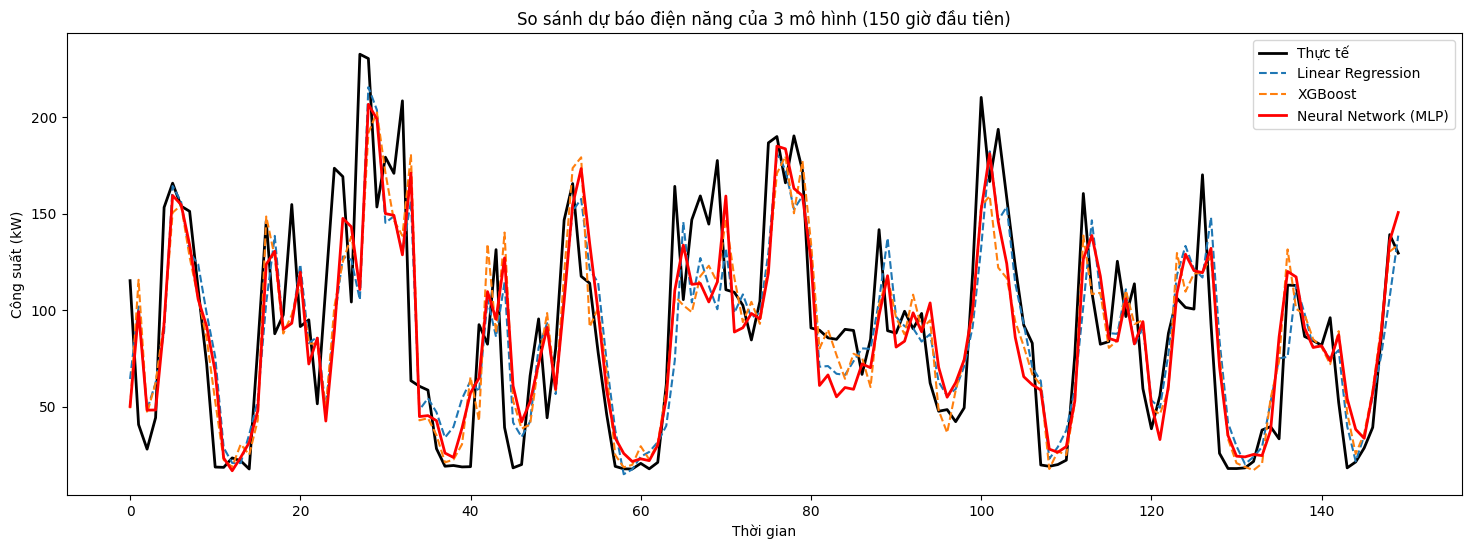

In [7]:

def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return [name, rmse, mae, r2]


results = []
results.append(evaluate_model('Linear Regression', y_test_inv, y_pred_lr_inv))
results.append(evaluate_model('XGBoost', y_test_inv, y_pred_xgb_inv))
results.append(evaluate_model('Neural Network (MLP)', y_test_inv, y_pred_mlp_inv))

df_results = pd.DataFrame(results, columns=['Model', 'RMSE', 'MAE', 'R2 Score'])
print("=== BẢNG SO SÁNH HIỆU QUẢ CÁC MÔ HÌNH ===")
display(df_results)


plt.figure(figsize=(18, 6))
plt.plot(y_test_inv[:150], label='Thực tế', color='black', linewidth=2)
plt.plot(y_pred_lr_inv[:150], label='Linear Regression', linestyle='--')
plt.plot(y_pred_xgb_inv[:150], label='XGBoost', linestyle='--')
plt.plot(y_pred_mlp_inv[:150], label='Neural Network (MLP)', color='red', linewidth=2)
plt.title('So sánh dự báo điện năng của 3 mô hình (150 giờ đầu tiên)')
plt.ylabel('Công suất (kW)')
plt.xlabel('Thời gian')
plt.legend()
plt.show()